# Exercices de calcul haute performance - Traduction et solutions

## Énoncé traduit en français

### Exercice 1 : Calcul explicite 3D – Accélération et efficacité parallèle

Soit un schéma explicite pour un problème 3D sur une grille de points de calcul de taille $m \times m \times m$. On étudie l'accélération (speedup) en fonction du nombre de nœuds de calcul $N$ et l'efficacité parallèle en fonction de la granularité (taille du sous‑domaine). On considère trois types de partitionnement : **1D**, **2D** et **3D**.

Chaque pas de temps nécessite :

#### 1. Calcul
- Opérations par point de grille : $k = 10$
- Temps par opération : $a = 1$
- Nombre de points dans le sous‑domaine d’un nœud : $Q$
- Temps de calcul :
$$ t_{\mathrm{cal}} = a \cdot k \cdot Q = 10\,Q $$

#### 2. Communication
- Échange des données des points de la surface du sous‑domaine avec les voisins.
- Un échange unique coûte :
$$ t_{\mathrm{comm}} = t_{\mathrm{lat}} + b \cdot P $$
  - Latence : $t_{\mathrm{lat}} = 100$
  - Largeur de bande inverse : $b = 1$
  - $P$ : volume de données échangé

Selon le partitionnement :
- **1D** : 2 étapes de communication
- **2D** : 4 étapes
- **3D** : 6 étapes

### Travail demandé
Pour chaque type de partitionnement (1D, 2D, 3D) :

- Établir la relation entre l’accélération (speedup) et le nombre de nœuds $N$.
- Établir la relation entre l’efficacité parallèle et la granularité.
- Discuter les domaines d’application de chaque méthode de partitionnement.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# Exercice 1 : modélisation speedup / efficacité

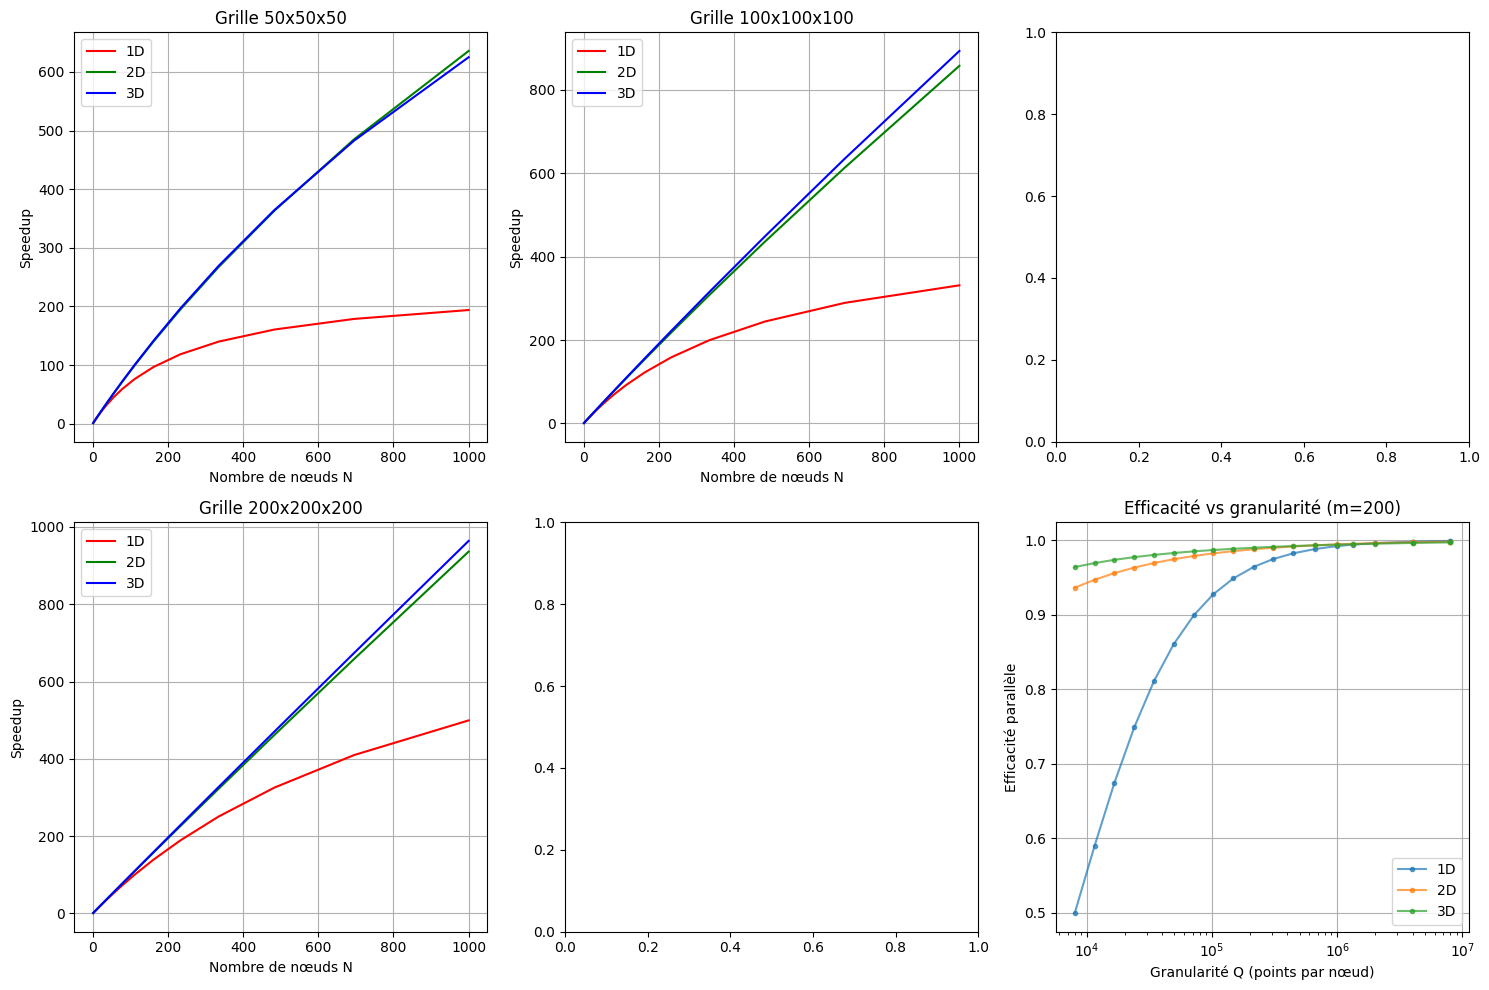

Discussion :
- Partition 1D : la communication ne diminue pas avec N (surface fixe m^2). Speedup plafonne très vite.
  Utilisable seulement pour des grilles très petites en y,z ou si la bande passante est énorme.
- Partition 2D : la communication diminue en 1/√N. Meilleure scalabilité, adaptée aux grilles modérées.
- Partition 3D : la communication diminue en 1/N^{2/3}, meilleure scalabilité asymptotique.
  Idéal pour les très grandes grilles et les supercalculateurs.
L'efficacité croît avec la granularité (plus de calcul par nœud masque la communication).



In [12]:
def compute_times(m, N, partition):
    """
    Calcule les temps de calcul et de communication pour un pas de temps.
    m : taille de la grille (m x m x m)
    N : nombre de nœuds
    partition : '1D', '2D' ou '3D'
    Retourne : t_cal, t_comm
    """
    total_points = m**3
    Q = total_points / N                # points par sous-domaine
    t_cal = 10 * Q                      # a=1, k=10
    
    if partition == '1D':
        # surface d'une face : m * m = m^2
        # 2 étapes de communication, chaque envoi m^2 données
        t_comm = 2 * (100 + m**2)
    elif partition == '2D':
        # partition carrée : N_x = N_y = sqrt(N)
        # surface par face : m * (m/sqrt(N)) = m^2 / sqrt(N)
        # 4 étapes
        t_comm = 4 * (100 + m**2 / np.sqrt(N))
    elif partition == '3D':
        # partition cubique : N_x = N_y = N_z = N^{1/3}
        # surface par face : (m/N^{1/3})^2 = m^2 / N^{2/3}
        # 6 étapes
        t_comm = 6 * (100 + m**2 / (N**(2/3)))
    else:
        raise ValueError("partition doit être '1D','2D' ou '3D'")
    return t_cal, t_comm

# Paramètres
m_values = [50, 100, 200]          # différentes tailles de grille
N_range = np.logspace(0, 3, 20, dtype=int)  # de 1 à 1000 nœuds

# Tracés pour différentes tailles de grille
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
partitions = ['1D', '2D', '3D']
colors = ['r', 'g', 'b']

for idx_m, m in enumerate(m_values):
    speedup_dict = {}
    for p in partitions:
        S = []
        # Temps série (N=1) : pas de communication
        t_serial, _ = compute_times(m, 1, p)   # pour N=1, t_comm=0 ?
        # Pour N=1, notre formule donne communication non nulle (car m^2...) -> corriger
        # On impose t_comm=0 pour N=1 (pas de voisins)
        t_serial = 10 * m**3   # temps série exact
        
        for N in N_range:
            if N > m**3: continue   # pas plus de nœuds que de points
            t_cal, t_comm = compute_times(m, N, p)
            t_total = t_cal + t_comm
            S.append(t_serial / t_total)
        speedup_dict[p] = (N_range[N_range <= m**3], S)
    
    # Sous-figure pour cette taille m
    ax = axes[idx_m // 2, idx_m % 2]
    for p, col in zip(partitions, colors):
        N_vals, S_vals = speedup_dict[p]
        ax.plot(N_vals, S_vals, label=p, color=col)
    ax.set_xlabel('Nombre de nœuds N')
    ax.set_ylabel('Speedup')
    ax.set_title(f'Grille {m}x{m}x{m}')
    ax.legend()
    ax.grid(True)

# Efficacité en fonction de la granularité Q = points par nœud
ax_e = axes[1, 2]
for p in partitions:
    Q_vals = []
    Eff_vals = []
    for N in N_range:
        if N > m**3: continue
        t_cal, t_comm = compute_times(m, N, p)
        t_total = t_cal + t_comm
        Q = m**3 / N
        S = (10*m**3) / t_total
        Eff = S / N
        Q_vals.append(Q)
        Eff_vals.append(Eff)
    ax_e.plot(Q_vals, Eff_vals, label=p, marker='.', alpha=0.7)
ax_e.set_xscale('log')
ax_e.set_xlabel('Granularité Q (points par nœud)')
ax_e.set_ylabel('Efficacité parallèle')
ax_e.set_title('Efficacité vs granularité (m=200)')
ax_e.legend()
ax_e.grid(True)

plt.tight_layout()
plt.show()

# Discussion (texte)
print("""Discussion :
- Partition 1D : la communication ne diminue pas avec N (surface fixe m^2). Speedup plafonne très vite.
  Utilisable seulement pour des grilles très petites en y,z ou si la bande passante est énorme.
- Partition 2D : la communication diminue en 1/√N. Meilleure scalabilité, adaptée aux grilles modérées.
- Partition 3D : la communication diminue en 1/N^{2/3}, meilleure scalabilité asymptotique.
  Idéal pour les très grandes grilles et les supercalculateurs.
L'efficacité croît avec la granularité (plus de calcul par nœud masque la communication).
""")

### Exercice 2 : Équilibrage de charge (stratégie de répartition des « pommes de terre »)

1. Reformuler la « stratégie pomme de terre 1 » en un problème d’allocation équilibrée des quantités de calcul.  

2. Programmation (langage libre) :  
   - Générer $m$ nombres aléatoires uniformes dans $[0,1]$. Prendre leur carré comme charge de calcul de chaque tâche.  
   - Répartir ces tâches sur $n$ nœuds de calcul selon la stratégie 2 (allocation la plus équilibrée possible).  
   - Les vitesses des nœuds sont :  
     a) $V_i = 1$ pour tous ;  
     b) $V_i = i$ (indice du nœud, $i=1,\dots,n$).  
   - Pour chaque cas, fournir : charge totale, charge par nœud, le degré d’équilibrage.  
   - Pour le cas **seulement** (1) ($m=20,\ n=3$), donner le détail de l’allocation (quelles tâches sur quel nœud).

Les jeux de données :  
(1) $m = 20,\ n = 3$  
(2) $m = 200,\ n = 5$ et $n = 10$  
(3) $m = 2000,\ n = 5,\ 10,\ 20$

In [13]:
def generer_taches(m):
    """Génère m tâches avec poids = (random[0,1])^2"""
    random.seed(42)   # reproductibilité
    return [random.random()**2 for _ in range(m)]

def repartition_greedy(taches, vitesses):
    """
    Algorithme glouton : attribue chaque tâche (triée décroissante)
    au nœud qui minimise le temps total final (temps = charge / vitesse).
    Retourne : allocation (liste d'indices des tâches par nœud),
               charge par nœud (somme des poids), temps par nœud.
    """
    n = len(vitesses)
    indices_taches = list(range(len(taches)))
    # tri par poids décroissant pour meilleure balance
    indices_taches.sort(key=lambda i: taches[i], reverse=True)
    
    # listes pour stocker les indices des tâches sur chaque nœud
    allocation = [[] for _ in range(n)]
    # temps courant sur chaque nœud (charge / vitesse)
    temps = [0.0] * n
    
    for idx in indices_taches:
        poids = taches[idx]
        # choisir le nœud qui aura le plus petit temps final après ajout
        meilleur = min(range(n), key=lambda i: temps[i] + poids/vitesses[i])
        allocation[meilleur].append(idx)
        temps[meilleur] += poids / vitesses[meilleur]
    
    # charges réelles (somme des poids) par nœud
    charges = [sum(taches[i] for i in alloc) for alloc in allocation]
    return allocation, charges, temps

def degre_equilibrage(temps):
    """Retourne le rapport temps_max / temps_moyen"""
    t_max = max(temps)
    t_moy = sum(temps) / len(temps)
    return t_max / t_moy

# Cas (1) m=20, n=3
m1, n1 = 20, 3
taches1 = generer_taches(m1)
vitesses1a = [1, 1, 1]
vitesses1b = [1, 2, 3]

alloc1a, charges1a, temps1a = repartition_greedy(taches1, vitesses1a)
alloc1b, charges1b, temps1b = repartition_greedy(taches1, vitesses1b)

print("=== Cas (1) m=20, n=3 ===")
print("Tâches (poids) :", [round(w,3) for w in taches1])
print("\nVitesses uniformes V_i=1 :")
print("Allocation (indices des tâches par nœud) :")
for i, alloc in enumerate(alloc1a):
    print(f"  Nœud {i}: tâches {alloc}")
print(f"Charges par nœud : {[round(c,3) for c in charges1a]}")
print(f"Temps par nœud : {[round(t,3) for t in temps1a]}")
print(f"Degré d'équilibrage (max/moyen) : {degre_equilibrage(temps1a):.3f}")

print("\nVitesses proportionnelles V_i = i :")
for i, alloc in enumerate(alloc1b):
    print(f"  Nœud {i+1} (vitesse {i+1}): tâches {alloc}")
print(f"Charges par nœud : {[round(c,3) for c in charges1b]}")
print(f"Temps par nœud : {[round(t,3) for t in temps1b]}")
print(f"Degré d'équilibrage : {degre_equilibrage(temps1b):.3f}")

# Fonction pour traiter les autres cas
def traiter_cas(m, n, vitesses_type):
    taches = generer_taches(m)
    if vitesses_type == 'uniformes':
        vitesses = [1]*n
    else:  # proportionnelles
        vitesses = list(range(1, n+1))
    alloc, charges, temps = repartition_greedy(taches, vitesses)
    total_charge = sum(charges)
    return total_charge, charges, temps, degre_equilibrage(temps)

print("\n=== Autres cas ===")
for (m, n_list) in [(200, [5,10]), (2000, [5,10,20])]:
    for n in n_list:
        for vt in ['uniformes', 'proportionnelles']:
            total, charges, temps, bal = traiter_cas(m, n, vt)
            print(f"\nm={m}, n={n}, vitesses {vt}:")
            print(f"  Charge totale = {total:.3f}")
            print(f"  Charges par nœud = {[round(c,3) for c in charges]}")
            print(f"  Temps par nœud = {[round(t,3) for t in temps]}")
            print(f"  Degré d'équilibrage = {bal:.3f}")

=== Cas (1) m=20, n=3 ===
Tâches (poids) : [0.409, 0.001, 0.076, 0.05, 0.542, 0.458, 0.796, 0.008, 0.178, 0.001, 0.048, 0.255, 0.001, 0.04, 0.422, 0.297, 0.049, 0.347, 0.655, 0.0]

Vitesses uniformes V_i=1 :
Allocation (indices des tâches par nœud) :
  Nœud 0: tâches [6, 0, 11, 16, 13]
  Nœud 1: tâches [18, 14, 15, 2, 3, 10]
  Nœud 2: tâches [4, 5, 17, 8, 7, 9, 12, 1, 19]
Charges par nœud : [1.548, 1.548, 1.535]
Temps par nœud : [1.548, 1.548, 1.535]
Degré d'équilibrage (max/moyen) : 1.003

Vitesses proportionnelles V_i = i :
  Nœud 1 (vitesse 1): tâches [5, 11, 16, 7, 12, 19]
  Nœud 2 (vitesse 2): tâches [18, 14, 15, 2, 3, 13, 9, 1]
  Nœud 3 (vitesse 3): tâches [6, 4, 0, 17, 8, 10]
Charges par nœud : [0.77, 1.541, 2.32]
Temps par nœud : [0.77, 0.771, 0.773]
Degré d'équilibrage : 1.003

=== Autres cas ===

m=200, n=5, vitesses uniformes:
  Charge totale = 64.022
  Charges par nœud = [12.804, 12.804, 12.804, 12.805, 12.804]
  Temps par nœud = [12.804, 12.804, 12.804, 12.805, 12.804]
  D